In [47]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False


In [58]:

class InboundAnalyzer:
    def __init__(self, db_path):
        self.db_path = db_path

    def _query(self, sql):
        conn = sqlite3.connect(self.db_path)
        df = pd.read_sql_query(sql, conn)
        conn.close()
        return df

    def get_yearly_totals(self):
        sql = """
        SELECT country, year, SUM(visitors) AS total
        FROM inbound_country
        GROUP BY country, year;
        """
        return self._query(sql)
    def get_recovery_rate(self, base_year=2019, exclude_aggregate=True, min_base_total=0):
        condition = ""
        if exclude_aggregate:
            condition += """
            AND y2019.country NOT LIKE '%その他%'
            AND y2019.country NOT LIKE '%計%'
            AND y2019.country NOT LIKE '%地域%'
            AND y2019.country NOT LIKE '%か国%'
            AND y2019.country NOT LIKE '%総計%'
            """

        if min_base_total and min_base_total > 0:
            condition += f"\nAND y2019.total >= {int(min_base_total)}\n"

        sql = f"""
        WITH yearly AS (
            SELECT country, year, SUM(visitors) AS total
            FROM inbound_country
            GROUP BY country, year
        ),
        latest AS (
            SELECT MAX(year) AS y FROM inbound_country
        )
        SELECT
            y2019.country,
            y2019.total AS base_total,
            ylatest.total AS latest_total,
            1.0 * ylatest.total / y2019.total AS recovery_rate
        FROM yearly y2019
        JOIN latest ON 1=1
        JOIN yearly ylatest
        ON ylatest.country = y2019.country
        AND ylatest.year = latest.y
        WHERE y2019.year = {base_year}
        AND y2019.total > 0
        {condition}
        ORDER BY recovery_rate DESC;
        """
        return self._query(sql)


    def plot_recovery(self, base_year=2019, top_n=10, exclude_aggregate=True, min_base_total=0):
        df = self.get_recovery_rate(
            base_year=base_year,
            exclude_aggregate=exclude_aggregate,
            min_base_total=min_base_total
        ).head(top_n)

        plt.figure(figsize=(10, 5))
        plt.bar(df["country"], df["recovery_rate"])
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Recovery Rate (latest / {base_year}) - Top {top_n}")
        plt.ylabel("Recovery Rate")
        plt.tight_layout()
        plt.show()


In [69]:
analyzer = InboundAnalyzer("dsprog_fin.db")
df_recovery = analyzer.get_recovery_rate(base_year=2019, exclude_aggregate=True, min_base_total=50000)
df_recovery.head(20)

,country,base_total,latest_total,recovery_rate
0,ＵＳＡ,691872,3036025,4.388131
1,カナダ,162208,630856,3.889179
2,オーストラリア,259992,937078,3.604257
3,スペイン,130243,231907,1.780572
4,イタリア,162769,287664,1.767314
5,ドイツ,236544,409095,1.729467
6,インド,175896,291744,1.658616
7,ロシア,120043,186675,1.555068
8,韓国,5584597,8485344,1.519419
9,インドネシア,412779,558880,1.353945


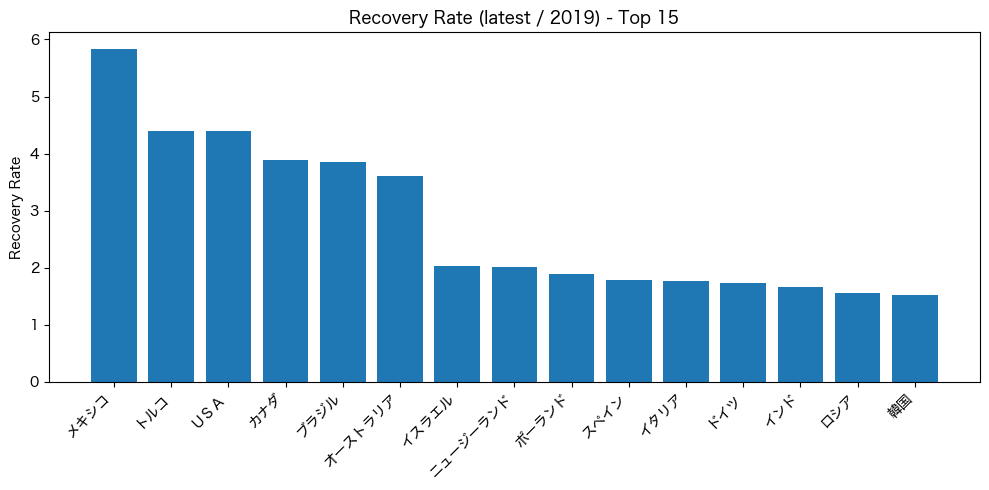

In [61]:
analyzer.plot_recovery(base_year=2019, top_n=15)


In [62]:
df_recovery["recovery_rate"].describe()


count    46.000000
mean      1.867933
std       1.098839
min       0.707179
25%       1.248818
50%       1.503999
75%       1.922088
max       5.830610
Name: recovery_rate, dtype: float64

In [71]:
df_recovery.head(20)


,country,base_total,latest_total,recovery_rate
0,ＵＳＡ,691872,3036025,4.388131
1,カナダ,162208,630856,3.889179
2,オーストラリア,259992,937078,3.604257
3,スペイン,130243,231907,1.780572
4,イタリア,162769,287664,1.767314
5,ドイツ,236544,409095,1.729467
6,インド,175896,291744,1.658616
7,ロシア,120043,186675,1.555068
8,韓国,5584597,8485344,1.519419
9,インドネシア,412779,558880,1.353945


In [72]:
top10 = df_recovery.sort_values("recovery_rate", ascending=False).head(10)

top10


,country,base_total,latest_total,recovery_rate
0,ＵＳＡ,691872,3036025,4.388131
1,カナダ,162208,630856,3.889179
2,オーストラリア,259992,937078,3.604257
3,スペイン,130243,231907,1.780572
4,イタリア,162769,287664,1.767314
5,ドイツ,236544,409095,1.729467
6,インド,175896,291744,1.658616
7,ロシア,120043,186675,1.555068
8,韓国,5584597,8485344,1.519419
9,インドネシア,412779,558880,1.353945


In [73]:

bottom10 = df_recovery.sort_values("recovery_rate").head(10)
bottom10

,country,base_total,latest_total,recovery_rate
23,マカオ,121197,85708,0.707179
22,タイ,1318977,1059104,0.802974
21,中国,9594394,8765808,0.913639
20,香港,2290792,2226216,0.971811
19,マレーシア,501592,536042,1.068681
18,英国,424279,500344,1.179281
17,スウェーデン,53836,63737,1.183910
16,シンガポール,492252,585567,1.189568
15,スイス,53908,66455,1.232748
14,フィリピン,613114,769505,1.255077


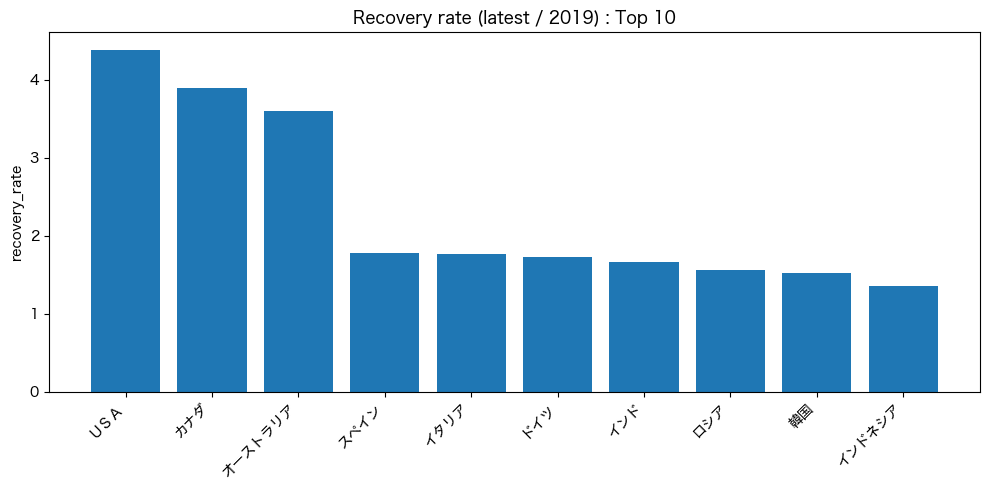

In [74]:
plt.figure(figsize=(10,5))
plt.bar(top10["country"], top10["recovery_rate"])
plt.xticks(rotation=45, ha="right")
plt.title("Recovery rate (latest / 2019) : Top 10")
plt.ylabel("recovery_rate")
plt.tight_layout()
plt.show()


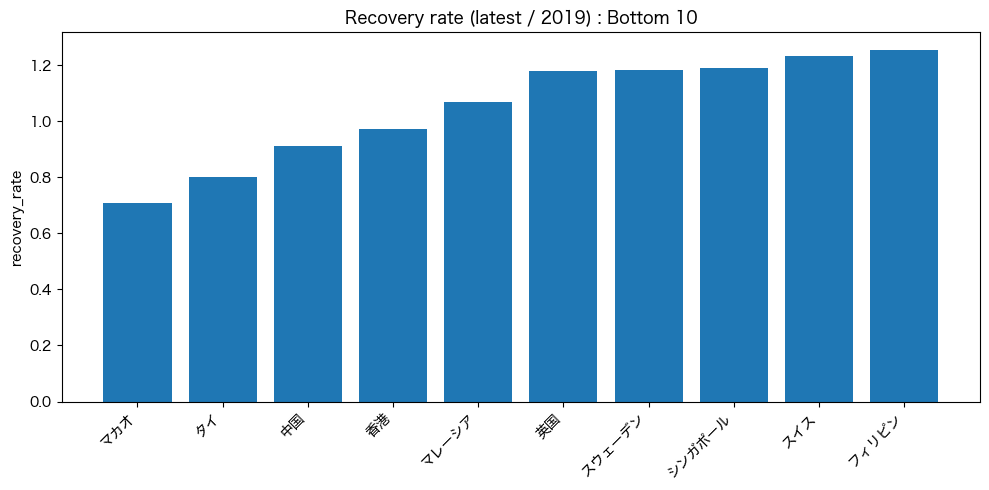

In [75]:
plt.figure(figsize=(10,5))
plt.bar(bottom10["country"], bottom10["recovery_rate"])
plt.xticks(rotation=45, ha="right")
plt.title("Recovery rate (latest / 2019) : Bottom 10")
plt.ylabel("recovery_rate")
plt.tight_layout()
plt.show()
